Imports e lettura dei dati

In [149]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)

In [150]:
actors = pd.read_csv('dataSets/mainDataSet/actors.csv')
countries = pd.read_csv('dataSets/mainDataSet/countries.csv')
crew = pd.read_csv('dataSets/mainDataSet/crew.csv')
genres = pd.read_csv('dataSets/mainDataSet/genres.csv')
languages = pd.read_csv('dataSets/mainDataSet/languages.csv')
movies = pd.read_csv('dataSets/mainDataSet/movies.csv')
posters = pd.read_csv('dataSets/mainDataSet/posters.csv') #potrebbe non servire in analisi dati
releases = pd.read_csv('dataSets/mainDataSet/releases.csv') #potrebbe non servire in analisi dati
studios = pd.read_csv('dataSets/mainDataSet/studios.csv')
themes = pd.read_csv('dataSets/mainDataSet/themes.csv') #potrebbe non servire in analisi dati

,id,country,date,type,rating
0,1000001,Andorra,2023-07-21,Theatrical,NaN
1,1000001,Argentina,2023-07-20,Theatrical,ATP
2,1000001,Australia,2023-07-19,Theatrical,PG
3,1000001,Australia,2023-10-01,Digital,PG
4,1000001,Austria,2023-07-20,Theatrical,NaN
...,...,...,...,...,...
1332777,1940967,USA,1909-01-01,Theatrical,NaN
1332778,1940968,Sweden,1908-11-11,Theatrical,NaN
1332779,1940969,France,1902-01-01,Theatrical,NaN
1332780,1940970,France,1902-01-01,Theatrical,NaN


In [151]:
languages

,id,type,language
0,1000001,Language,English
1,1000002,Primary language,Korean
2,1000002,Spoken language,English
3,1000002,Spoken language,German
4,1000002,Spoken language,Korean
...,...,...,...
1038757,1941593,Language,Chinese
1038758,1941594,Language,English
1038759,1941595,Language,English
1038760,1941596,Language,Chinese


capire il dataset

In [152]:
countries.nunique()

id         617192
country       247
dtype: int64

In [153]:
countries['country'].value_counts()

country
USA                                  174489
France                                45725
UK                                    42914
Japan                                 41362
Germany                               41325
                                      ...  
Niue                                      2
Heard Island and McDonald Islands         2
Cocos (Keeling) Islands                   1
Bouvet Island                             1
Norfolk Island                            1
Name: count, Length: 247, dtype: int64

creo un subset di countries di paesi di interesse geopolitico e culturale, di paesi con piu film o paesi di interesse personale


In [154]:
paesi_di_interesse = [
    "USA", "France", "UK", "Japan", "Germany", "India", "Italy",
    "Mexico", "China", "Russian Federation", "South Korea", "USSR",
    "Philippines", "Czechoslovakia", "Poland", "Turkey",
    "Taiwan", "Czechia", "Iran", "Ukraine", "Ireland", "Israel",
    "South Africa", "Malaysia", "New Zealand", "Colombia", "East Germany",
    "Croatia", "Serbia", "Bulgaria", "Slovakia", "Kazakhstan"
]
sub_countries = countries[countries['country'].isin(paesi_di_interesse)]

In [155]:
sub_countries.count()

id         504888
country    504888
dtype: int64

creo un subset di film basato sul subset di countries di interesse

In [156]:
movies

,id,name,date,tagline,description,minute,rating
0,1000001,Barbie,2023.0,She's everything. He's just Ken.,Barbie and Ken are having the time of their li...,114.0,3.86
1,1000002,Parasite,2019.0,Act like you own the place.,"All unemployed, Ki-taek's family takes peculia...",133.0,4.56
2,1000003,Everything Everywhere All at Once,2022.0,The universe is so much bigger than you realize.,An aging Chinese immigrant is swept up in an i...,140.0,4.30
3,1000004,Fight Club,1999.0,Mischief. Mayhem. Soap.,A ticking-time-bomb insomniac and a slippery s...,139.0,4.27
4,1000005,La La Land,2016.0,Here's to the fools who dream.,"Mia, an aspiring actress, serves lattes to mov...",129.0,4.09
...,...,...,...,...,...,...,...
941592,1941593,神笛,NaN,NaN,NaN,NaN,NaN
941593,1941594,蟲極道蜜団子抗争編 壱ノ巻,NaN,NaN,Shinjuku forest at night. In the sap taverns o...,30.0,NaN
941594,1941595,蟲極道蜜団子抗争編 弐ノ巻,NaN,NaN,"The city that never sleeps, where insects gath...",30.0,NaN
941595,1941596,重生,NaN,NaN,"In a world where order has broken down, darkne...",NaN,NaN


In [157]:
id_filtrati = sub_countries['id'].unique()
df = movies[movies['id'].isin(id_filtrati)].copy()

In [158]:
df.count()

id             472298
name           472297
date           454522
tagline         89355
description    403126
minute         409236
rating          75496
dtype: int64

In [159]:
#creo dataframe, per ogni id di un film crea una lista contenente i paesi che l'hanno prodotto
#countries_aggregated = countries.groupby('id')['country'].apply(list).reset_index()

# Unisce il dataset dei film con i paesi aggregati
#df = pd.merge(movies_filtrati, countries_aggregated, on='id', how='inner')

In [160]:
#df

Merging all Data-sets by id

In [161]:
# Unisci i primi due dataset
#df = pd.merge(movies, countries, on='id', how='inner')

# Unisci il risultato con il terzo dataset
#df = pd.merge(df, ds3, on='id', how='inner')

# Continua fino a unire tutti i dataset
#df = pd.merge(df, ds4, on='id', how='inner')
#df = pd.merge(df, ds5, on='id', how='inner')
#df = pd.merge(df, ds6, on='id', how='inner')
#df = pd.merge(df, ds7, on='id', how='inner')
#df = pd.merge(df, ds8, on='id', how='inner')
#df = pd.merge(df, ds9, on='id', how='inner')
#df.head(1000)

pulizia dei dati

In [162]:
df

,id,name,date,tagline,description,minute,rating
0,1000001,Barbie,2023.0,She's everything. He's just Ken.,Barbie and Ken are having the time of their li...,114.0,3.86
1,1000002,Parasite,2019.0,Act like you own the place.,"All unemployed, Ki-taek's family takes peculia...",133.0,4.56
2,1000003,Everything Everywhere All at Once,2022.0,The universe is so much bigger than you realize.,An aging Chinese immigrant is swept up in an i...,140.0,4.30
3,1000004,Fight Club,1999.0,Mischief. Mayhem. Soap.,A ticking-time-bomb insomniac and a slippery s...,139.0,4.27
4,1000005,La La Land,2016.0,Here's to the fools who dream.,"Mia, an aspiring actress, serves lattes to mov...",129.0,4.09
...,...,...,...,...,...,...,...
941592,1941593,神笛,NaN,NaN,NaN,NaN,NaN
941593,1941594,蟲極道蜜団子抗争編 壱ノ巻,NaN,NaN,Shinjuku forest at night. In the sap taverns o...,30.0,NaN
941594,1941595,蟲極道蜜団子抗争編 弐ノ巻,NaN,NaN,"The city that never sleeps, where insects gath...",30.0,NaN
941595,1941596,重生,NaN,NaN,"In a world where order has broken down, darkne...",NaN,NaN


In [163]:
df.loc[df.duplicated(subset=['name', 'date', 'minute'])]

,id,name,date,tagline,description,minute,rating
41484,1041485,The Haunted Castle,1897.0,NaN,George Albert Smith's remake of Georges Méliès...,1.0,2.85
42715,1042716,The Darkness,2016.0,NaN,A family lives in a cabin in the middle of a s...,92.0,3.18
65400,1065401,Disclosure,2020.0,"There are two sides to every story, and then t...","Australian documentary maker Emily, and her jo...",107.0,3.44
73818,1073819,Better Than Sex,2000.0,3 days in the life of a 1 night stand.,After a one-night stand a couple is faced with...,84.0,3.24
73819,1073820,Amoklauf,1994.0,NaN,A nameless waiter spends his days sitting arou...,65.0,NaN
...,...,...,...,...,...,...,...
941049,1941050,The Bunker,NaN,We haven't much time...decide!,"On the brink of nuclear destruction, a mother ...",NaN,NaN
941088,1941089,The Daily Life of a Sexist Homosexual,NaN,NaN,This is what happens if you make a mockumentar...,24.0,NaN
941091,1941092,Dead in Love,NaN,It's never too late to come out... or fall in ...,The ghost of a bisexual young woman becomes en...,105.0,NaN
941120,1941121,Don't. Get. Out! 2,NaN,NaN,NaN,NaN,NaN


cancello tutte le righe duplicate

In [164]:
df = df.loc[~df.duplicated(subset=['name', 'date', 'minute'])].reset_index(drop=True).copy() #identifico come duplicati tutti i film con stesso nome data e durata

In [165]:
df.count()

id             470991
name           470990
date           453350
tagline         89200
description    402141
minute         408280
rating          75477
dtype: int64

In [166]:
df.loc[df['name'] == 'untitled']

,id,name,date,tagline,description,minute,rating
143056,1189343,untitled,NaN,NaN,NaN,NaN,NaN
203811,1295520,untitled,1994.0,NaN,NaN,NaN,NaN
204340,1296524,untitled,1996.0,NaN,NaN,NaN,NaN
204345,1296533,untitled,1993.0,NaN,NaN,NaN,NaN
204901,1297545,untitled,1995.0,NaN,NaN,NaN,NaN
205444,1298628,untitled,1992.0,NaN,NaN,NaN,NaN
467449,1933305,untitled,2019.0,NaN,NaN,3.0,NaN


cancello tutte le righe con nome del film "untitled"

In [167]:
maschera_da_eliminare = df['name'] == 'untitled'
df = df.drop(df[maschera_da_eliminare].index).copy()

cambio la colonna date in release_year

In [168]:
df = df.rename(columns={'date': 'release_year'}).copy()
df

,id,name,release_year,tagline,description,minute,rating
0,1000001,Barbie,2023.0,She's everything. He's just Ken.,Barbie and Ken are having the time of their li...,114.0,3.86
1,1000002,Parasite,2019.0,Act like you own the place.,"All unemployed, Ki-taek's family takes peculia...",133.0,4.56
2,1000003,Everything Everywhere All at Once,2022.0,The universe is so much bigger than you realize.,An aging Chinese immigrant is swept up in an i...,140.0,4.30
3,1000004,Fight Club,1999.0,Mischief. Mayhem. Soap.,A ticking-time-bomb insomniac and a slippery s...,139.0,4.27
4,1000005,La La Land,2016.0,Here's to the fools who dream.,"Mia, an aspiring actress, serves lattes to mov...",129.0,4.09
...,...,...,...,...,...,...,...
470986,1941593,神笛,NaN,NaN,NaN,NaN,NaN
470987,1941594,蟲極道蜜団子抗争編 壱ノ巻,NaN,NaN,Shinjuku forest at night. In the sap taverns o...,30.0,NaN
470988,1941595,蟲極道蜜団子抗争編 弐ノ巻,NaN,NaN,"The city that never sleeps, where insects gath...",30.0,NaN
470989,1941596,重生,NaN,NaN,"In a world where order has broken down, darkne...",NaN,NaN


In [169]:
df.dtypes

id                int64
name             object
release_year    float64
tagline          object
description      object
minute          float64
rating          float64
dtype: object

prime analisi?

In [170]:
df['release_year'].value_counts()

release_year
2023.0    21518
2021.0    18791
2022.0    18762
2019.0    17420
2020.0    17312
          ...  
1882.0        2
1874.0        1
2031.0        1
1885.0        1
1887.0        1
Name: count, Length: 149, dtype: int64

Text(0, 0.5, 'Numero di film')

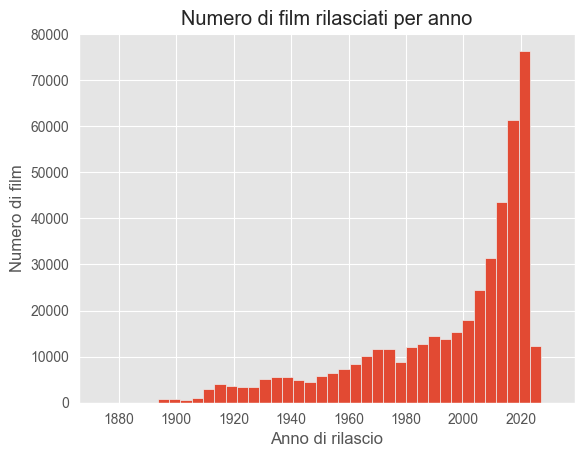

In [177]:
ax = df['release_year'].plot(kind='hist', bins=40, title='Numero di film rilasciati per anno')
ax.set_xlabel('Anno di rilascio')
ax.set_ylabel('Numero di film')

Text(0, 0.5, 'Numero di film')

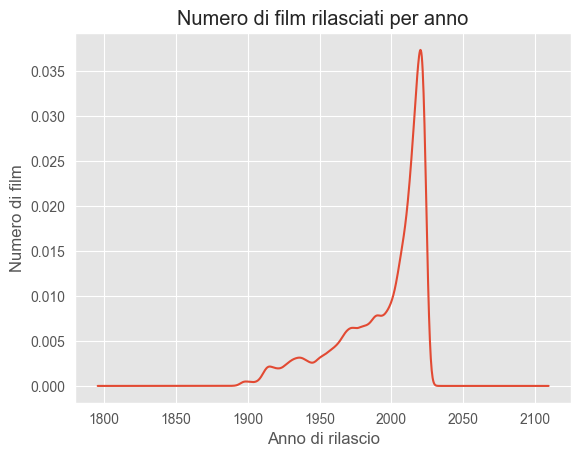

In [183]:
ax = df['release_year'].plot(kind='kde', title='Numero di film rilasciati per anno')
ax.set_xlabel('Anno di rilascio')
ax.set_ylabel('Numero di film')

<Axes: title={'center': 'incidenza del rating rispetto anno di rilascio'}, xlabel='release_year', ylabel='rating'>

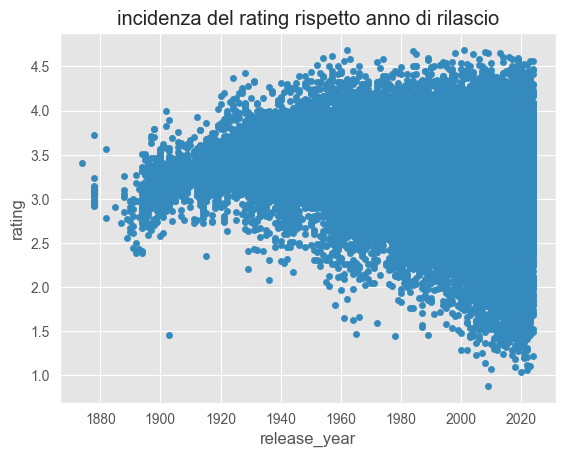

In [190]:
df.plot(kind='scatter', x='release_year', y='rating', title='incidenza del rating rispetto anno di rilascio')